# Beta Analyzer

Analisi dei file ROOT presi alle beta

Branch usati: `pmax`, `area_new`, `cfd` (tree `Analysis`)

In [9]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import moyal
from scipy.optimize import curve_fit
import os, glob, warnings
warnings.filterwarnings('ignore')

In [4]:
# ── Configurazione canali ─────────────────────────────────────────────────────
N_CHANNELS = 2           # numero di canali attivi nel file ROOT

MCP_CHANNEL = 1          # indice del canale MCP (-1 se non presente)
MCP_RESOLUTION_PS = 12   # risoluzione MCP [ps] (usata solo se MCP_CHANNEL >= 0)

# ── Derivati — non modificare ─────────────────────────────────────────────────
HAS_MCP = MCP_CHANNEL >= 0
DUT_CHANNELS = [ch for ch in range(N_CHANNELS) if ch != MCP_CHANNEL]
PAIRS = [(a, b) for a in range(N_CHANNELS) for b in range(a + 1, N_CHANNELS)]

print(f"Canali attivi  : {N_CHANNELS}")
print(f"DUT channels   : {DUT_CHANNELS}")
print(f"MCP channel    : {MCP_CHANNEL if HAS_MCP else 'nessuno'}")
print(f"Pairs CFD      : {PAIRS}")

Canali attivi  : 2
DUT channels   : [0]
MCP channel    : 1
Pairs CFD      : [(0, 1)]


In [10]:
#DATA_DIR = "/Users/leonardolanteri/Desktop/PhD/Data+Plots+Macros/ETL/BETA 2026/HPK6/Run5_HPK6_TS_S2A_LGAD-B_15E15"
DATA_DIR = "/Users/leonardolanteri/Desktop/PhD/Data+Plots+Macros/ETL/BETA 2026/FBK/Run12_PRE_LF-FBK_QC-TS_W16_S9_LGAD-B_15e15"
root_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.root")))
print(f"Found {len(root_files)} files:")
for f in root_files:
    print(" ", os.path.basename(f))

Found 9 files:
  stats_Sr_Run12_Ch0-300V_trig2750V.root
  stats_Sr_Run12_Ch0-350V_trig2750V.root
  stats_Sr_Run12_Ch0-400V_trig2750V.root
  stats_Sr_Run12_Ch0-450V_trig2750V.root
  stats_Sr_Run12_Ch0-500V_trig2750V.root
  stats_Sr_Run12_Ch0-525V_trig2750V.root
  stats_Sr_Run12_Ch0-550V_trig2750V.root
  stats_Sr_Run12_Ch0-575V_trig2750V.root
  stats_Sr_Run12_Ch0-600V_trig2750V.root


In [11]:
with uproot.open(root_files[0]) as f:
    tree = f["Analysis"]
    print(tree.keys())

['event', 'pmax', 'pmax_fit', 'tmax', 'tmax_fit', 'area', 'area_new', 'area_nc', 'area_fixed_window', 'dvdt', 'dvdt_2080', 'cfd', 'rms', 'chi2', 'time', 'I', 'V']


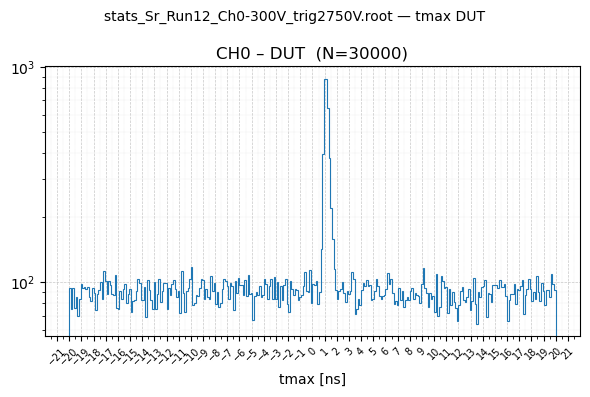

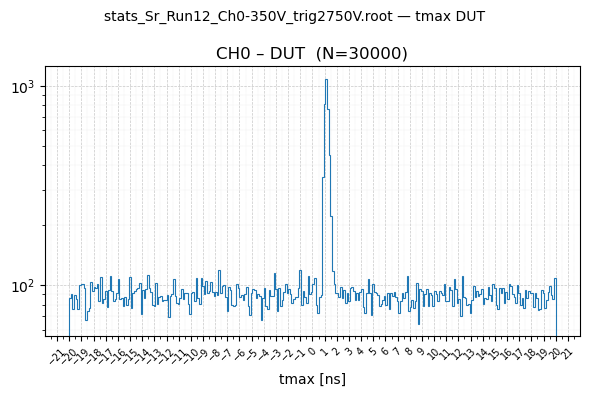

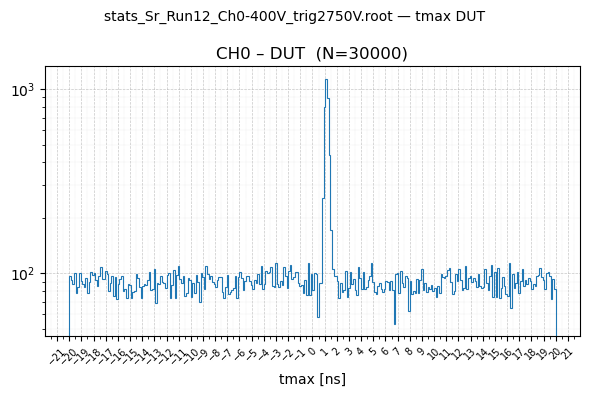

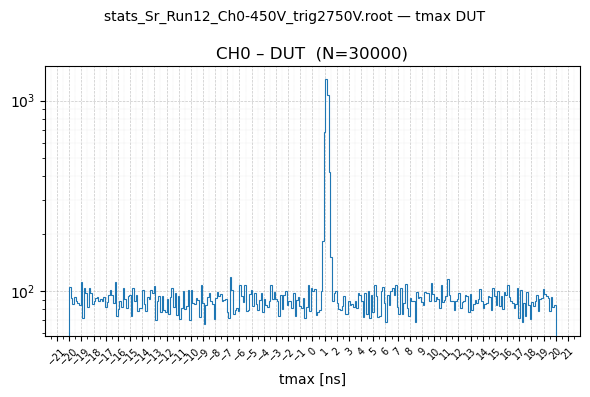

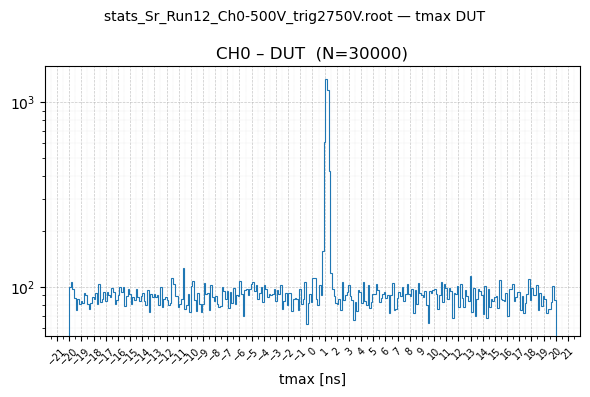

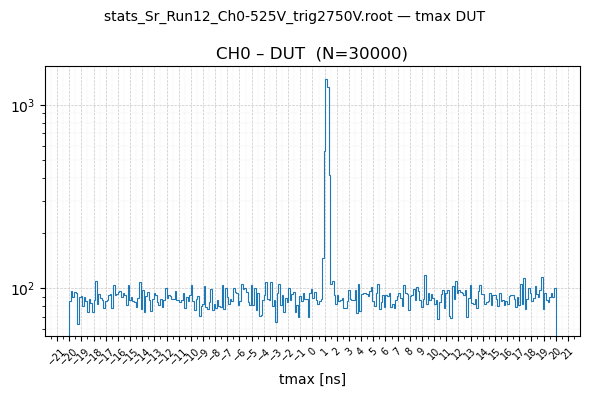

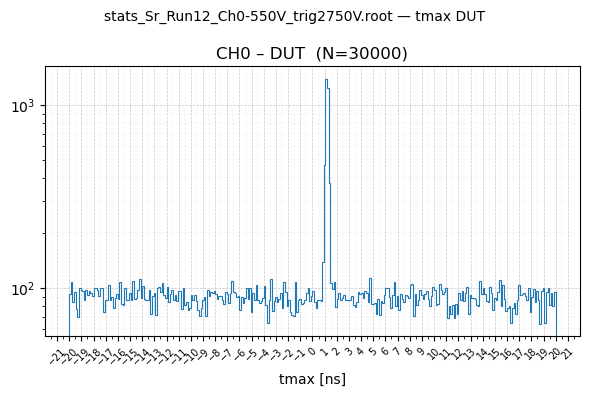

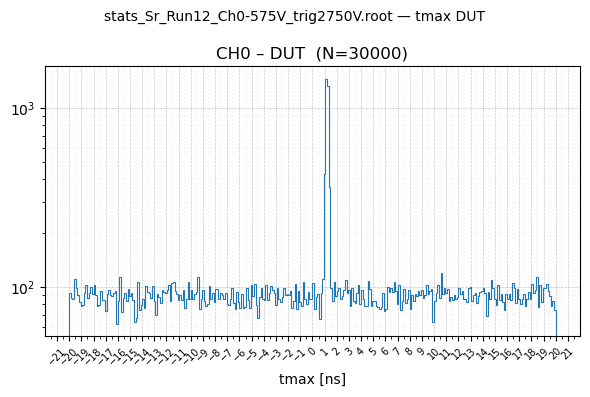

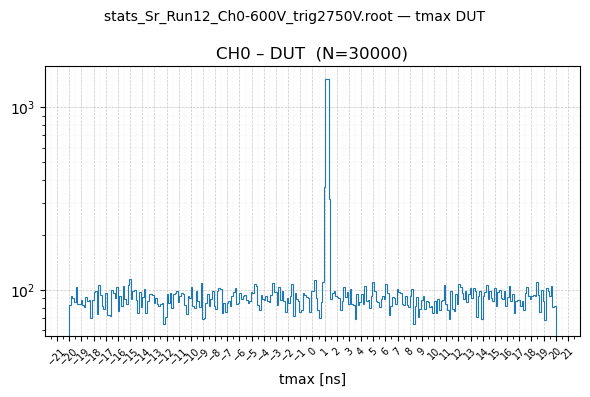

In [12]:
# ── tmax distribution per canali DUT (nessun taglio) ─────────────────────────
TMAX_BINS  = 300
TTICK_STEP = 1    # ns

for filepath in root_files:
    fname = os.path.basename(filepath)
    with uproot.open(filepath) as f:
        tmax_ak = f["Analysis"]["tmax"].array(library="ak")

    fig, axes = plt.subplots(1, len(DUT_CHANNELS), figsize=(6 * len(DUT_CHANNELS), 4))
    if len(DUT_CHANNELS) == 1:
        axes = [axes]
    fig.suptitle(f"{fname} — tmax DUT", fontsize=10)

    for ax, ch in zip(axes, DUT_CHANNELS):
        tm = ak.to_numpy(tmax_ak[:, ch]).astype(float)
        tm = tm[np.isfinite(tm)]
        ax.hist(tm, bins=TMAX_BINS, log=True, histtype='step', linewidth=0.8)
        ax.set_title(f"CH{ch} – DUT  (N={len(tm)})")
        ax.set_xlabel("tmax [ns]")
        ax.xaxis.set_major_locator(plt.MultipleLocator(TTICK_STEP))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(TTICK_STEP / 2))
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.5)
        ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

In [13]:
# ── Tagli su tmax (finestra per ogni canale DUT) ──────────────────────────────
# cuts_tmax[ch] = lista di tuple (t_min, t_max) [ns], una per file
# Usa -np.inf / np.inf per nessun taglio su un lato

cuts_tmax = {ch: [(0.5, 1.8)] * n for ch in DUT_CHANNELS}

# Esempio:
# cuts_tmax[0] = [(5.0, 15.0)] * n   # stessa finestra per tutti i file
# cuts_tmax[0] = [(5.0, 15.0), (5.0, 14.0), ...]  # diversa per ogni file

print("File order:")
for i, f in enumerate(root_files):
    print(f"  [{i}] {os.path.basename(f)}")
print()
for ch in DUT_CHANNELS:
    print(f"cuts_tmax[{ch}] = {cuts_tmax[ch]}")

NameError: name 'n' is not defined

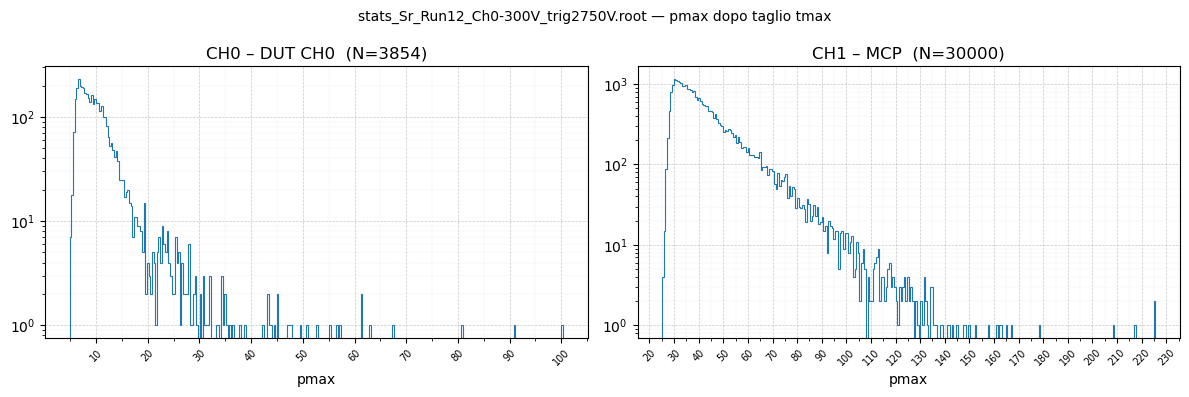

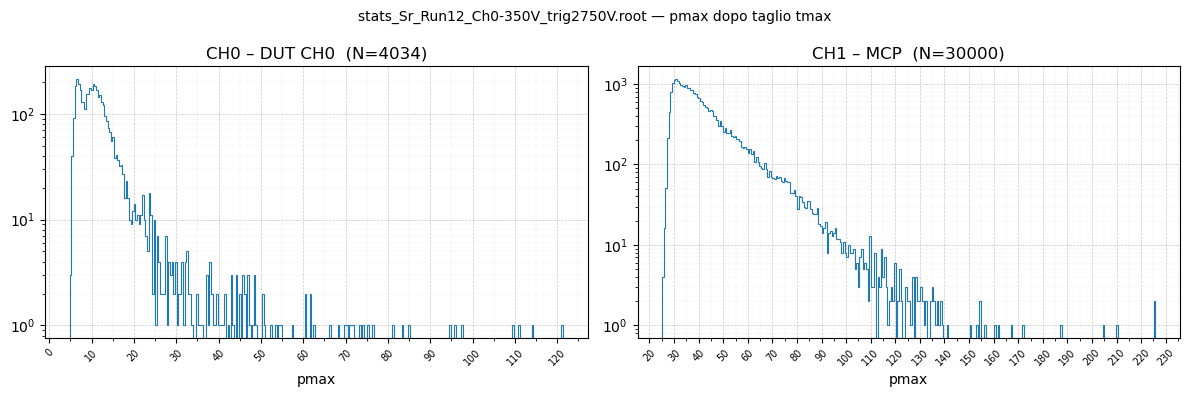

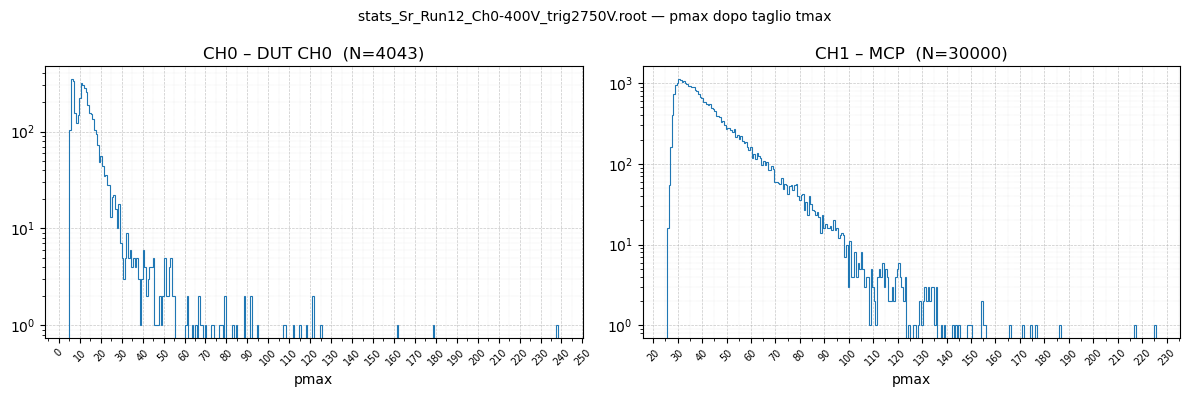

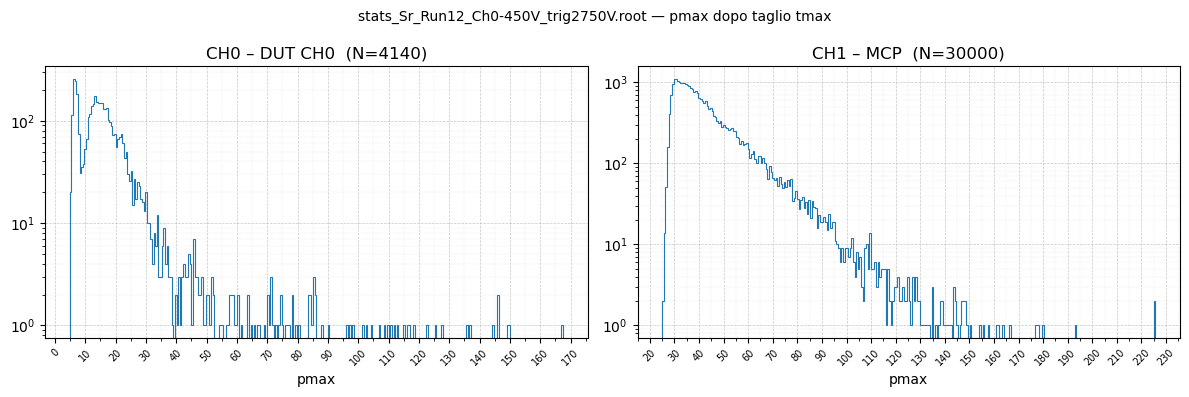

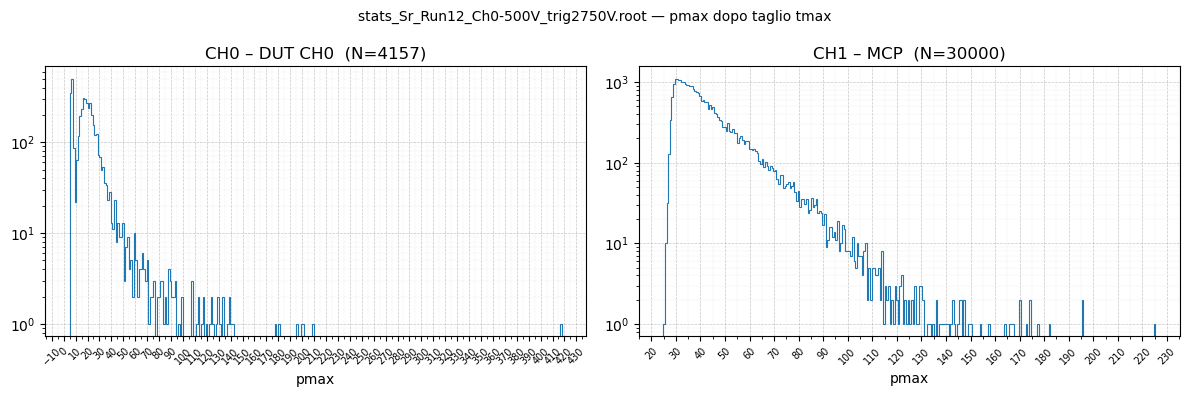

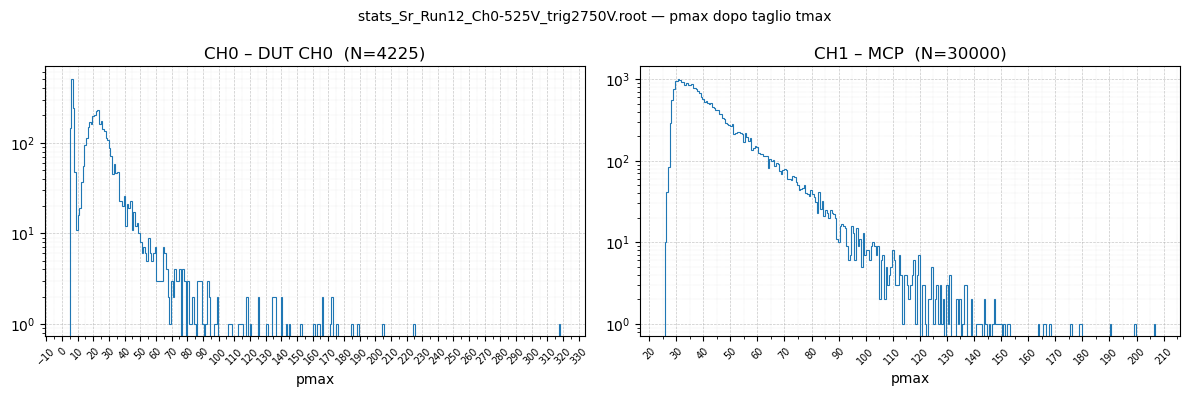

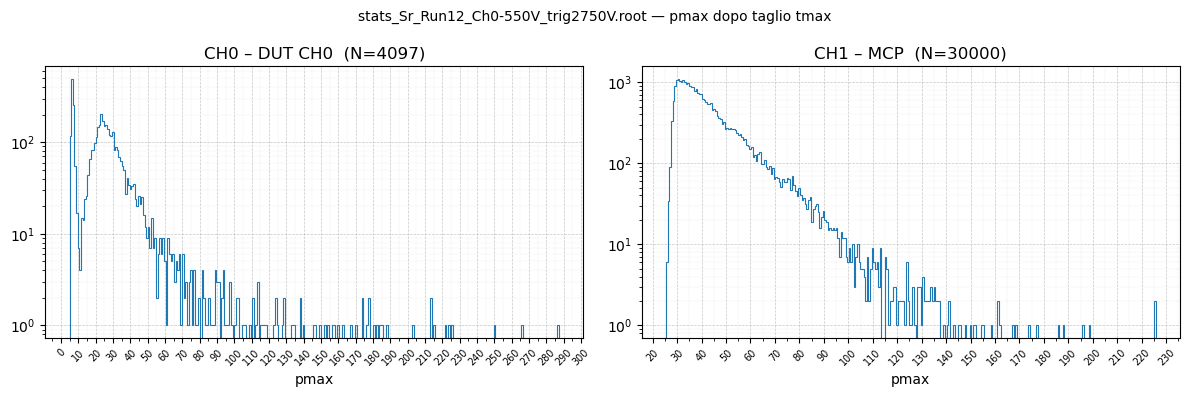

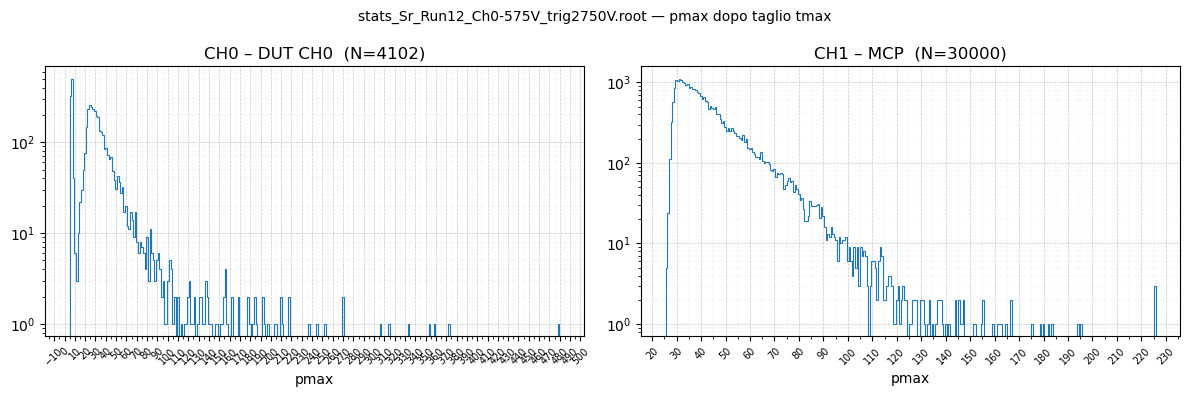

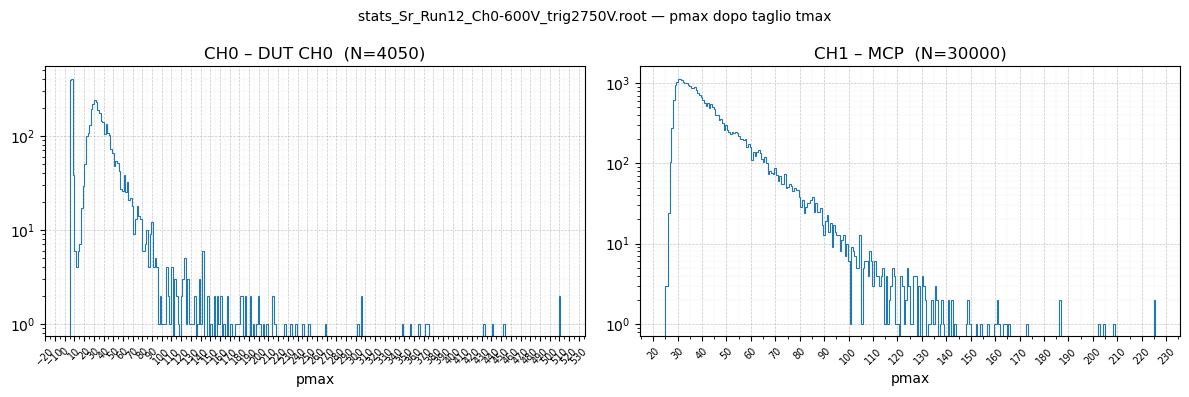

In [ ]:
# ── pmax plots filtrati per tmax (DUT channels) ───────────────────────────────
PMAX_BINS  = 300
XTICK_STEP = 10

for i, filepath in enumerate(root_files):
    fname = os.path.basename(filepath)
    with uproot.open(filepath) as f:
        pmax_ak = f["Analysis"]["pmax"].array(library="ak")
        tmax_ak = f["Analysis"]["tmax"].array(library="ak")

    fig, axes = plt.subplots(1, N_CHANNELS, figsize=(6 * N_CHANNELS, 4))
    if N_CHANNELS == 1:
        axes = [axes]
    fig.suptitle(f"{fname} — pmax dopo taglio tmax", fontsize=10)

    for ch in range(N_CHANNELS):
        lbl = 'MCP' if HAS_MCP and ch == MCP_CHANNEL else f'DUT CH{ch}'
        pm = ak.to_numpy(pmax_ak[:, ch]).astype(float)
        if ch in DUT_CHANNELS:
            tm = ak.to_numpy(tmax_ak[:, ch]).astype(float)
            t_lo, t_hi = cuts_tmax[ch][i]
            tmax_mask = (tm >= t_lo) & (tm <= t_hi)
            pm = pm[tmax_mask]
        ax = axes[ch]
        ax.hist(pm, bins=PMAX_BINS, log=True, histtype='step', linewidth=0.8)
        ax.set_title(f"CH{ch} – {lbl}  (N={len(pm)})")
        ax.set_xlabel("pmax")
        ax.xaxis.set_major_locator(plt.MultipleLocator(XTICK_STEP))
        ax.xaxis.set_minor_locator(plt.MultipleLocator(XTICK_STEP / 2))
        ax.tick_params(axis='x', labelsize=7, rotation=45)
        ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
        ax.grid(True, which='minor', linestyle=':', linewidth=0.3, alpha=0.5)
        ax.set_axisbelow(True)

    plt.tight_layout()
    plt.show()

In [ ]:
n = len(root_files)

# ── Tagli manuali su pmax ─────────────────────────────────────────────────────
cuts_pmax = {ch: [10.0] * n for ch in range(N_CHANNELS)}
cuts_pmax[0] = [10, 10, 15, 20, 20, 25, 30, 30, 30, 40]  # CH0

# ── Range e bin per il fit Gaussiano su Δcfd ──────────────────────────────────
cfd_bins  = 200
cfd_range = {pair: (0, 2) for pair in PAIRS}
# Esempio: cfd_range[(0,1)] = (-0.5, 2.5)

print("File order:")
for i, f in enumerate(root_files):
    print(f"  [{i}] {os.path.basename(f)}")
print()
for ch in range(N_CHANNELS):
    lbl = 'MCP' if HAS_MCP and ch == MCP_CHANNEL else 'DUT'
    print(f"cuts_pmax[{ch}]  # CH{ch} – {lbl} = {cuts_pmax[ch]}")
print()
for pair in PAIRS:
    print(f"cfd_range[{pair}] = {cfd_range[pair]}  ({cfd_bins} bin)")

File order:
  [0] stats_Sr_Run12_Ch0-300V_trig2750V.root
  [1] stats_Sr_Run12_Ch0-350V_trig2750V.root
  [2] stats_Sr_Run12_Ch0-400V_trig2750V.root
  [3] stats_Sr_Run12_Ch0-450V_trig2750V.root
  [4] stats_Sr_Run12_Ch0-500V_trig2750V.root
  [5] stats_Sr_Run12_Ch0-525V_trig2750V.root
  [6] stats_Sr_Run12_Ch0-550V_trig2750V.root
  [7] stats_Sr_Run12_Ch0-575V_trig2750V.root
  [8] stats_Sr_Run12_Ch0-600V_trig2750V.root

cuts_pmax[0]  # CH0 – DUT = [10, 10, 15, 20, 20, 25, 30, 30, 30, 40]
cuts_pmax[1]  # CH1 – MCP = [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]

cfd_range[(0, 1)] = (0, 2)  (200 bin)


In [ ]:
def fit_landau(x, amp, mu, sigma):
    return amp * moyal.pdf(x, mu, sigma)

def fit_gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def do_landau(data):
    counts, edges = np.histogram(data, bins=100)
    centers = 0.5 * (edges[:-1] + edges[1:])
    try:
        p0 = [counts.max(), centers[counts.argmax()], np.std(data) * 0.5]
        popt, pcov = curve_fit(fit_landau, centers, counts, p0=p0, maxfev=10000)
        return popt, np.sqrt(np.diag(pcov)), counts, edges
    except Exception:
        return [np.nan]*3, [np.nan]*3, counts, edges

def do_gauss(data, bins=100, hrange=None):
    counts, edges = np.histogram(data, bins=bins, range=hrange)
    centers = 0.5 * (edges[:-1] + edges[1:])
    try:
        p0 = [counts.max(), np.mean(data), np.std(data)]
        popt, pcov = curve_fit(fit_gaussian, centers, counts, p0=p0, maxfev=10000)
        return popt, np.sqrt(np.diag(pcov)), counts, edges
    except Exception:
        return [np.nan]*3, [np.nan]*3, counts, edges

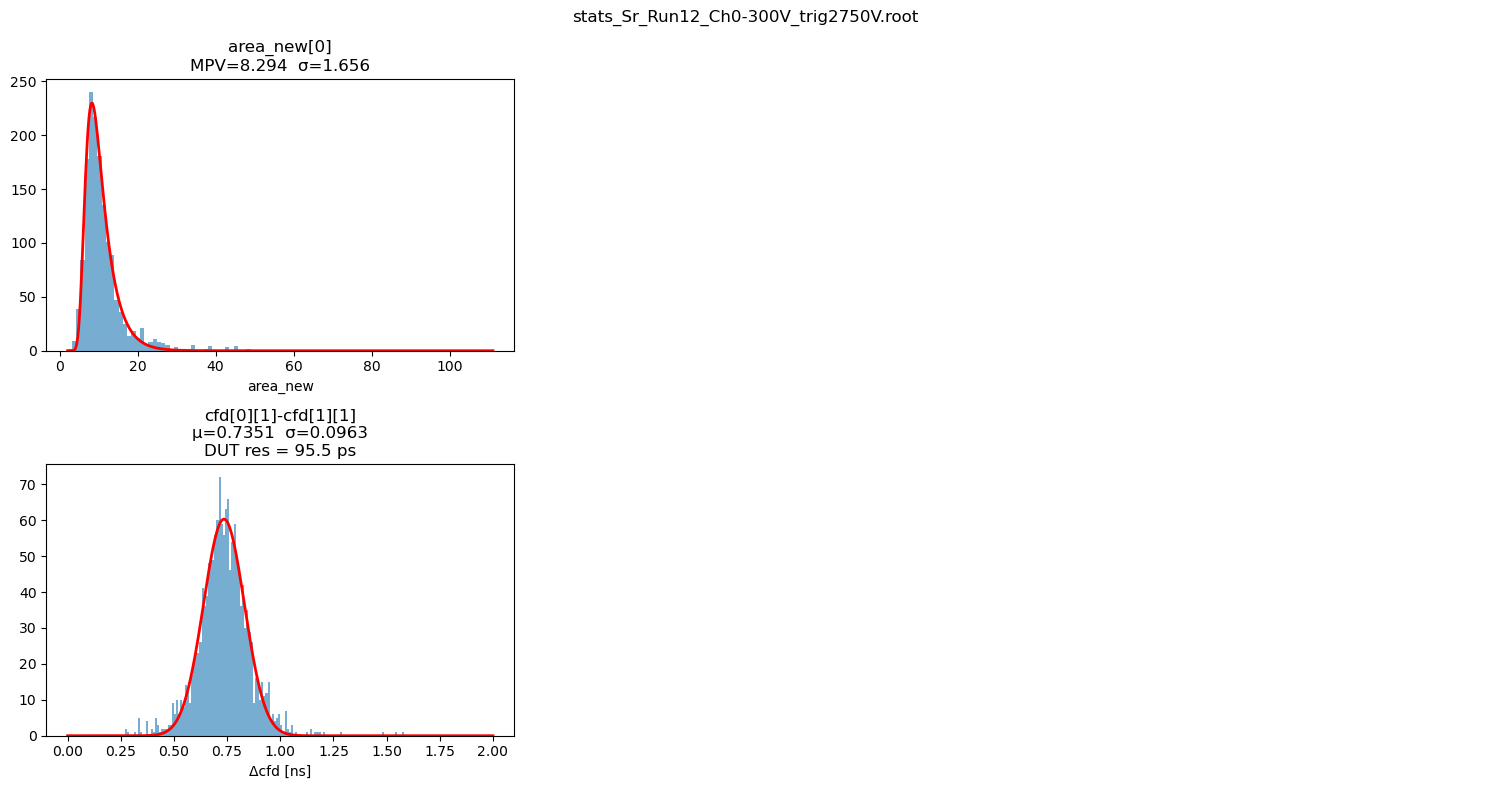

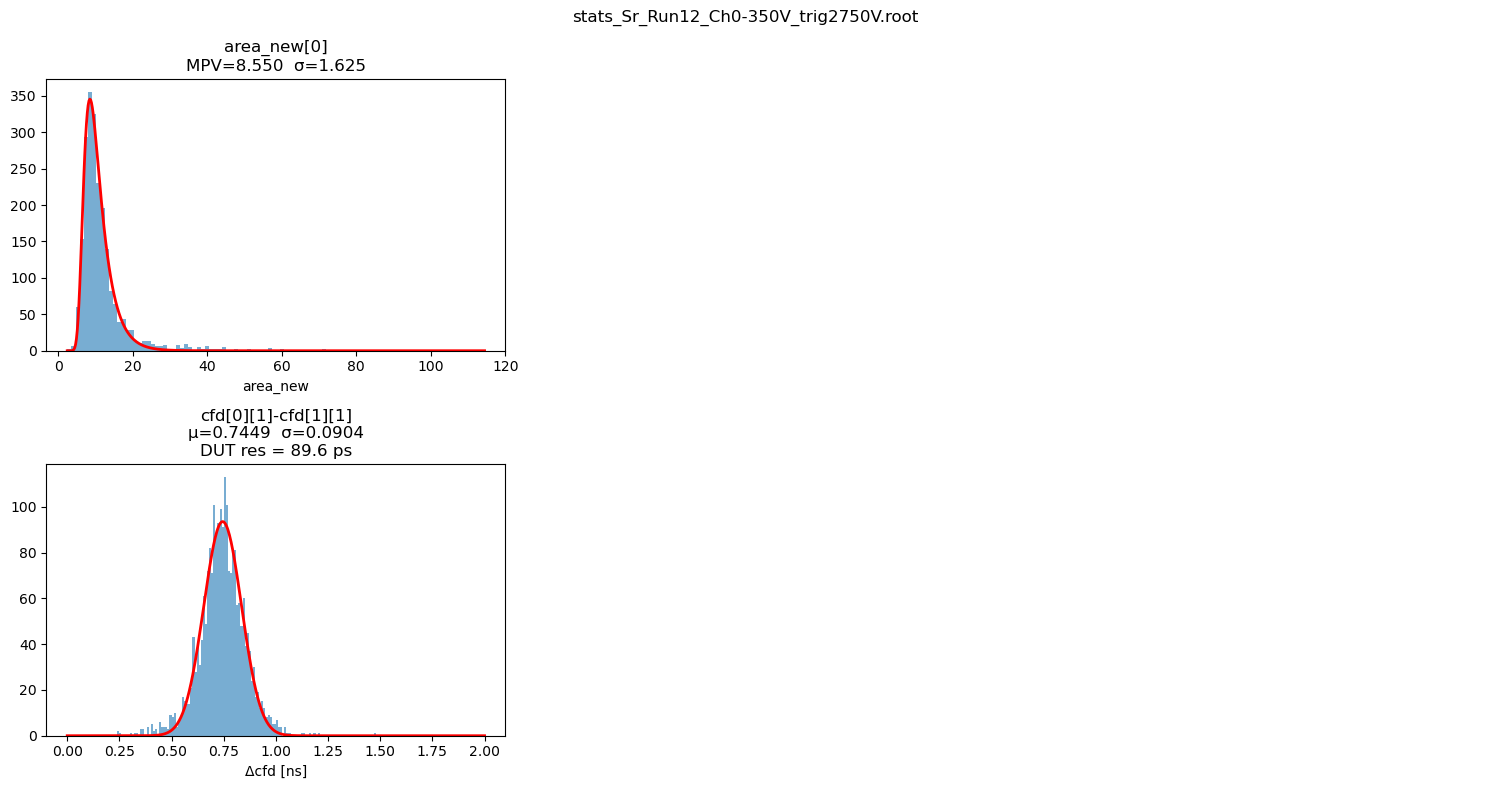

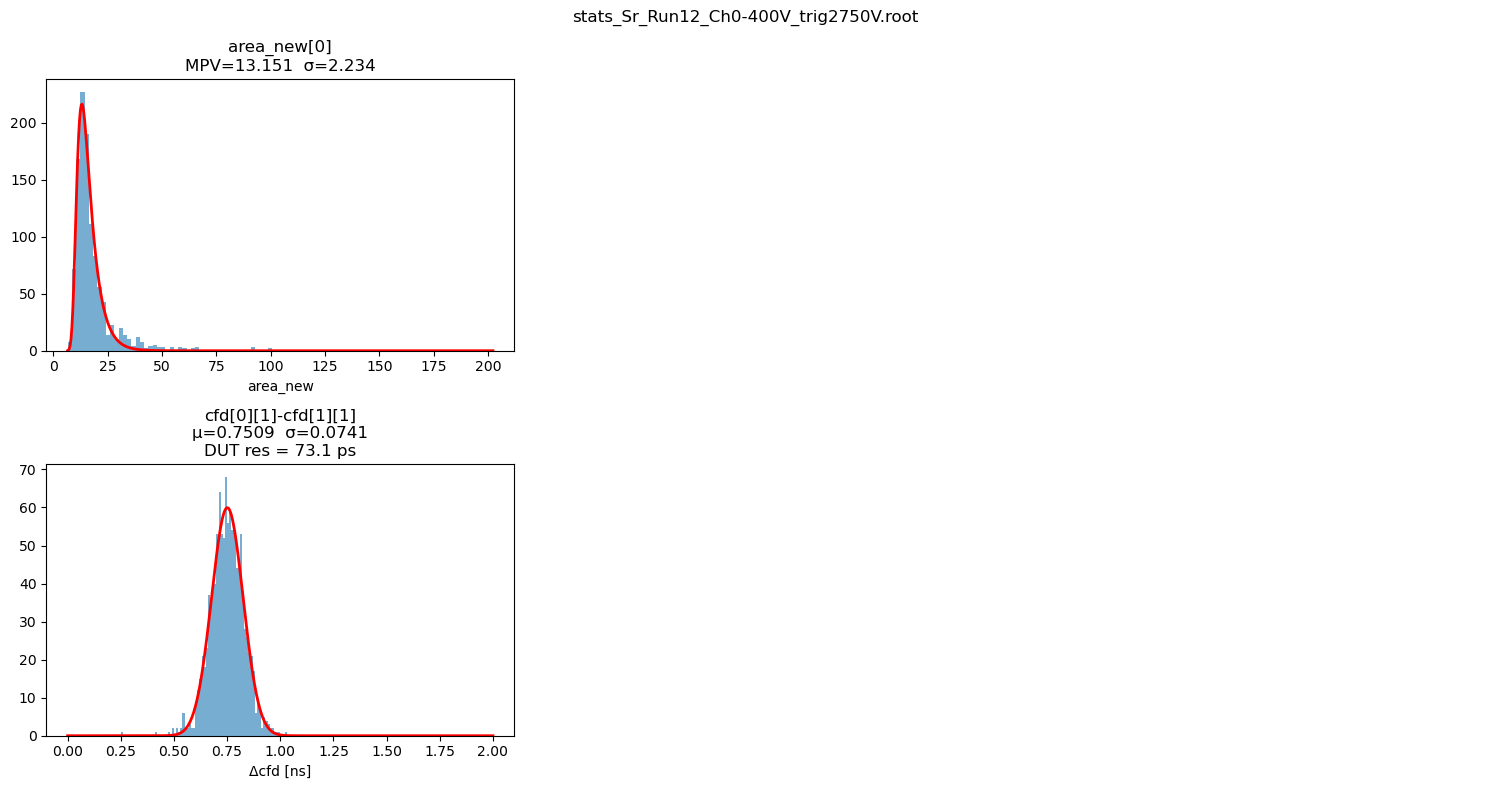

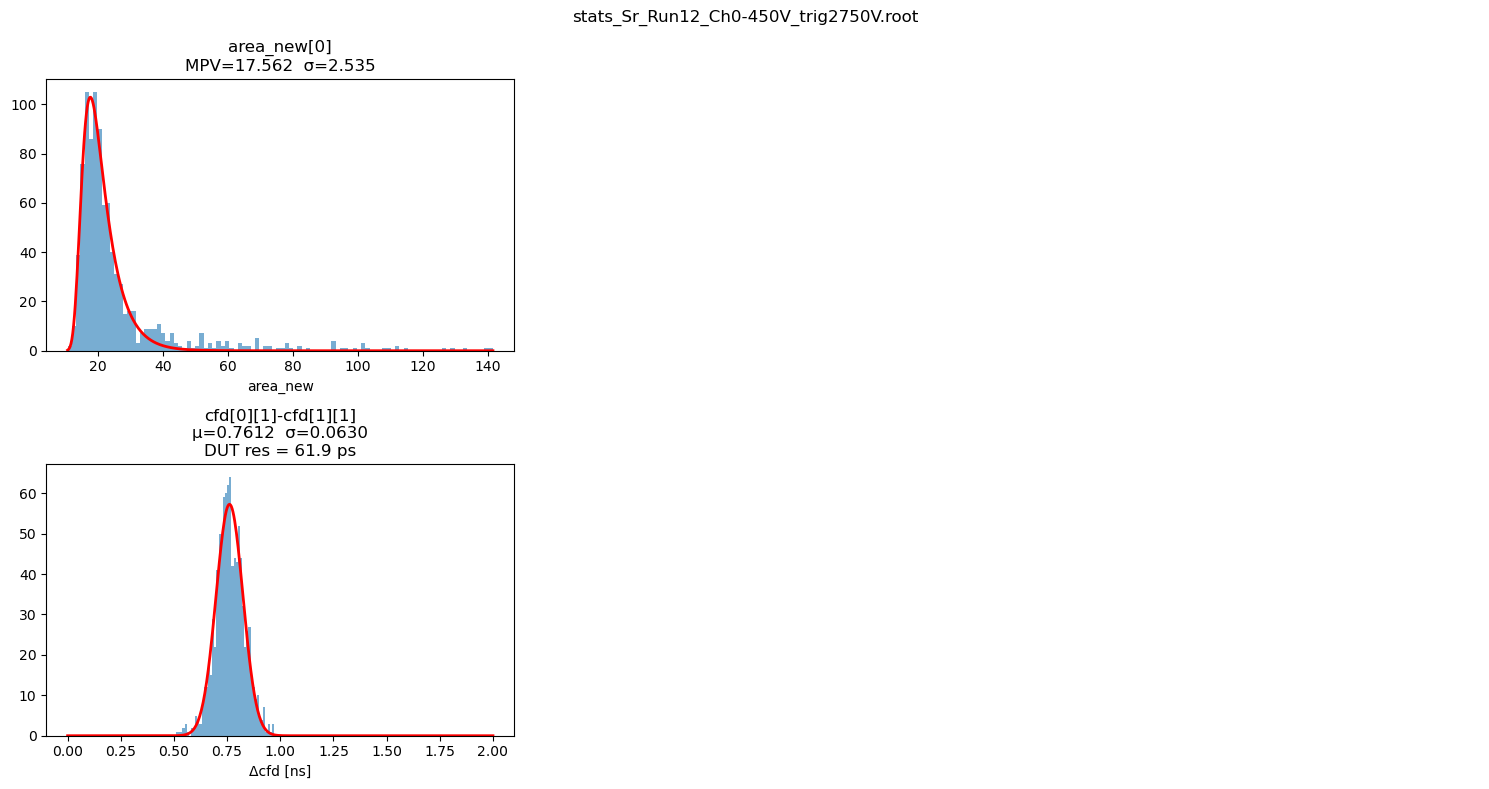

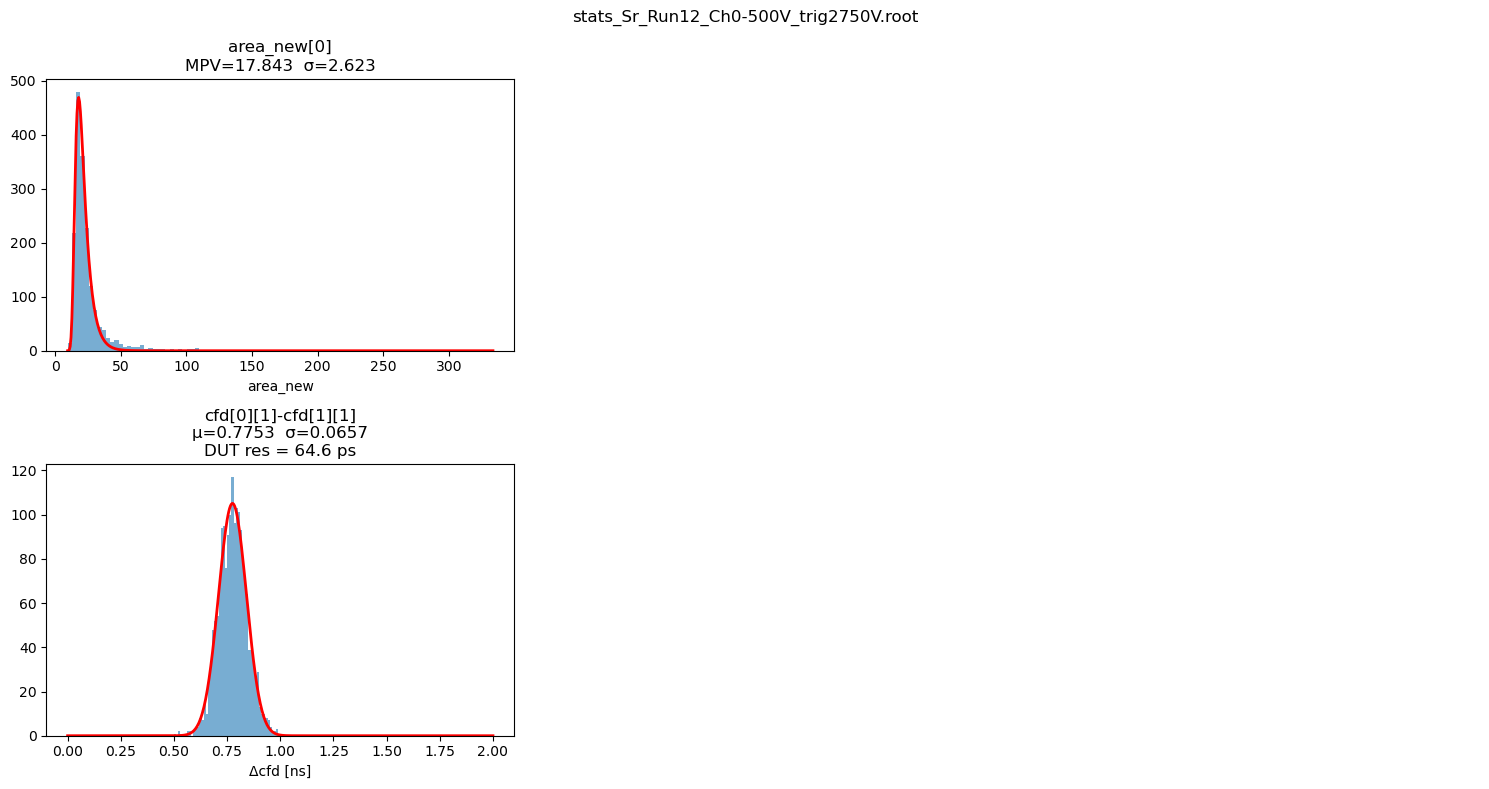

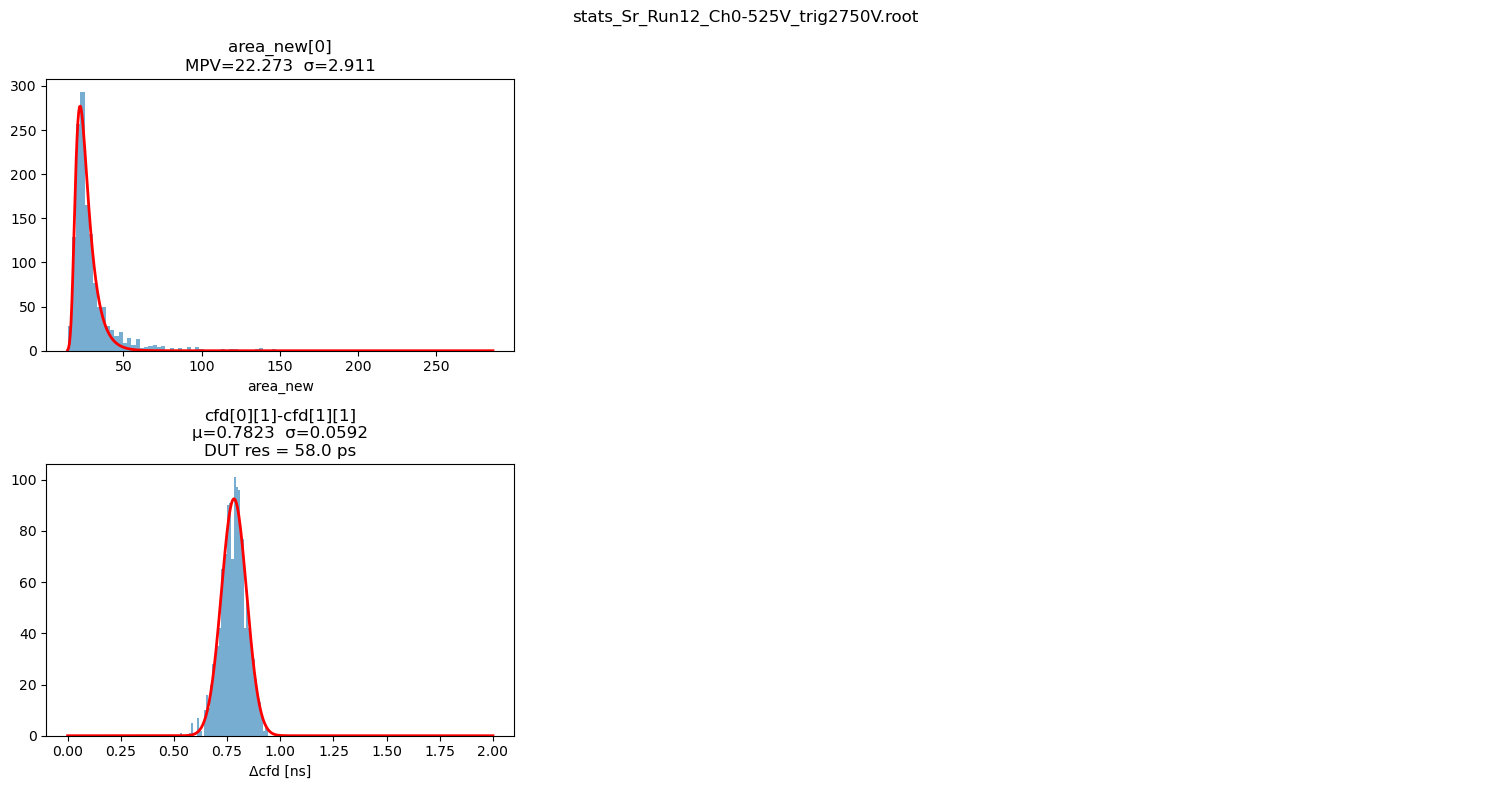

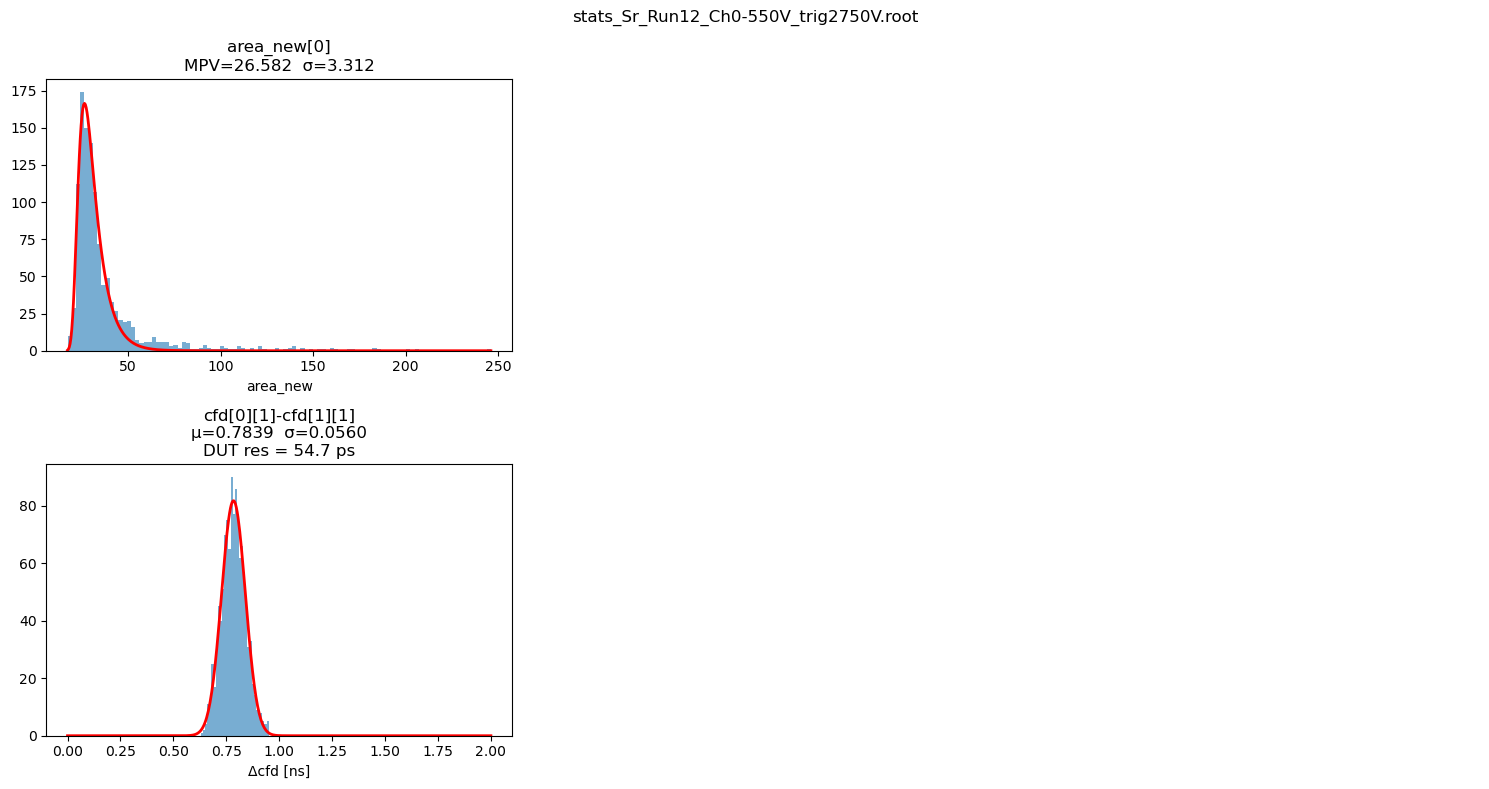

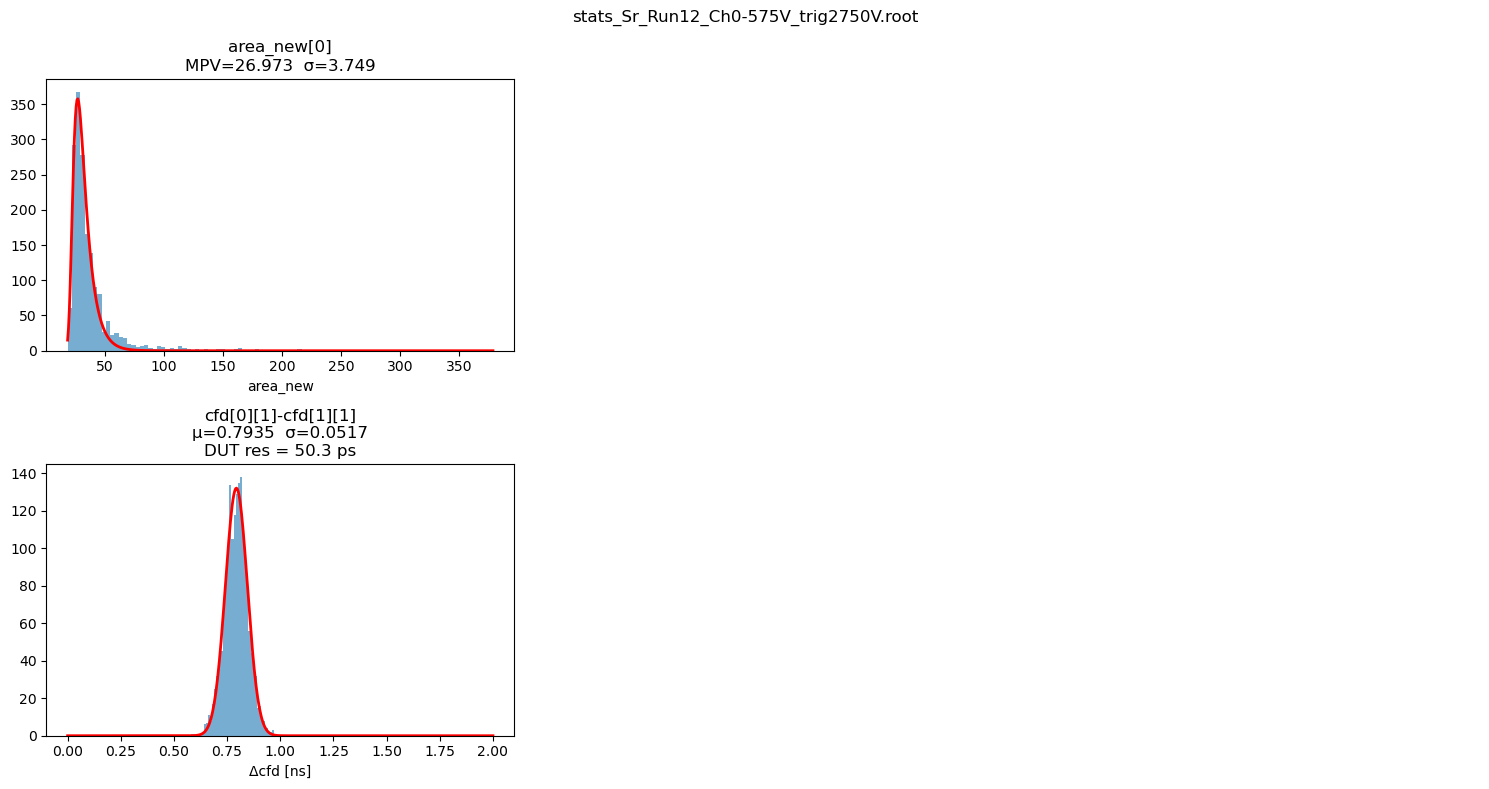

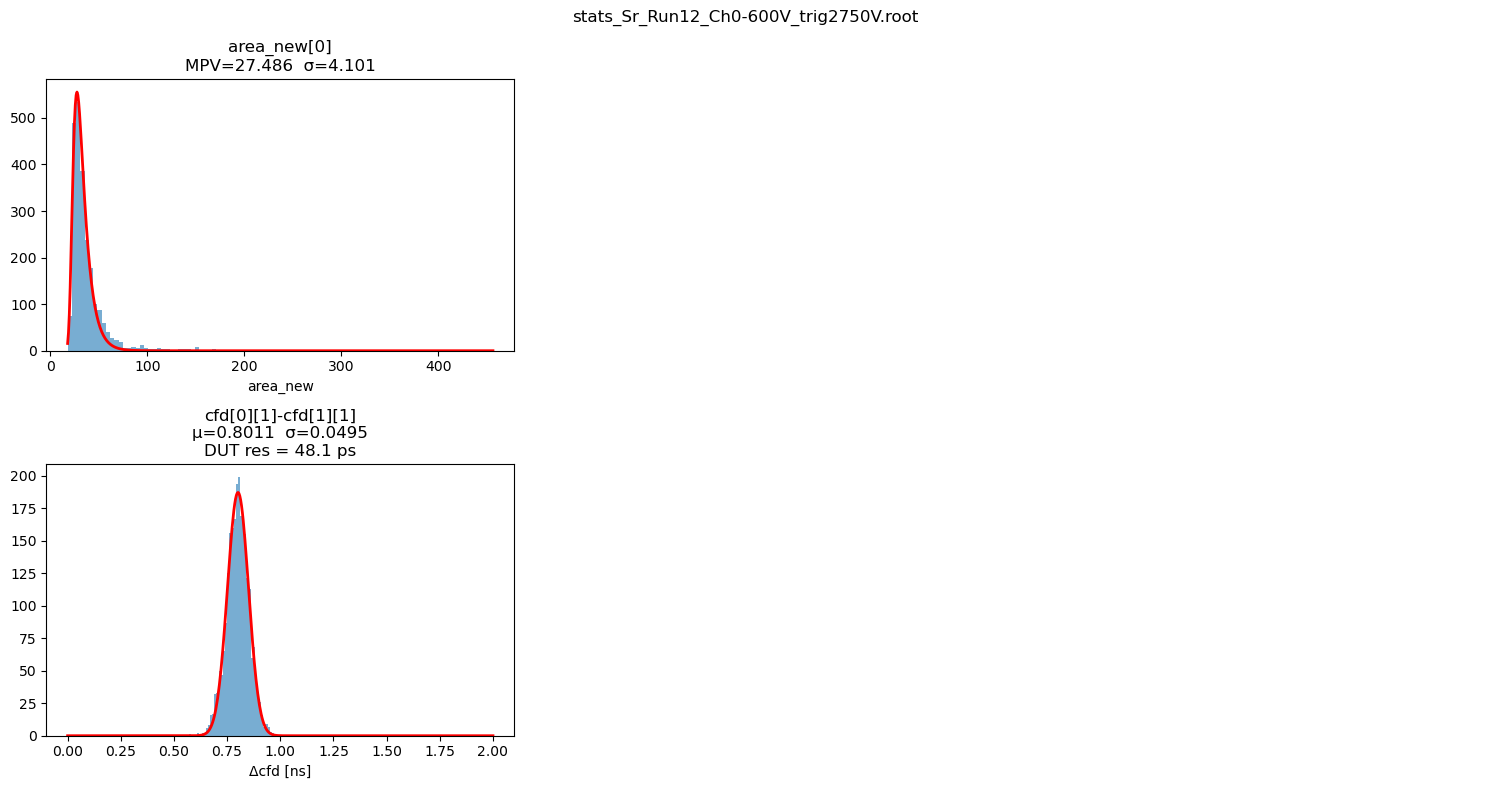

Done.


In [ ]:
results = []

for i, filepath in enumerate(root_files):
    fname = os.path.basename(filepath)

    with uproot.open(filepath) as f:
        tree    = f["Analysis"]
        pmax_ak = tree["pmax"].array(library="ak")
        tmax_ak = tree["tmax"].array(library="ak")
        area_ak = tree["area_new"].array(library="ak")
        cfd_ak  = tree["cfd"].array(library="ak")

    pm = {ch: ak.to_numpy(pmax_ak[:, ch]).astype(float) for ch in range(N_CHANNELS)}
    tm = {ch: ak.to_numpy(tmax_ak[:, ch]).astype(float) for ch in DUT_CHANNELS}

    # Maschera combinata tmax & pmax per DUT; solo pmax per MCP
    masks = {}
    for ch in range(N_CHANNELS):
        pmax_mask = pm[ch] > cuts_pmax[ch][i]
        if ch in DUT_CHANNELS:
            t_lo, t_hi = cuts_tmax[ch][i]
            tmax_mask  = (tm[ch] >= t_lo) & (tm[ch] <= t_hi)
            masks[ch]  = tmax_mask & pmax_mask
        else:
            masks[ch]  = pmax_mask

    pair_masks = {(a, b): masks[a] & masks[b] for (a, b) in PAIRS}

    # Landau su canali DUT
    landau_res = {}
    for ch in DUT_CHANNELS:
        data = ak.to_numpy(area_ak[masks[ch], ch]).astype(float)
        data = data[np.isfinite(data)]
        landau_res[ch] = do_landau(data)

    # Gauss su tutte le coppie CFD
    gauss_res = {}
    cfd_diffs = {}
    for (a, b) in PAIRS:
        m    = pair_masks[(a, b)]
        diff = (ak.to_numpy(cfd_ak[m, a, 1]).astype(float) -
                ak.to_numpy(cfd_ak[m, b, 1]).astype(float))
        diff = diff[np.isfinite(diff)]
        cfd_diffs[(a, b)] = diff
        gauss_res[(a, b)] = do_gauss(diff, bins=cfd_bins, hrange=cfd_range[(a, b)])

    # ── layout plot ───────────────────────────────────────────────────────────
    ncols     = 3
    n_land    = len(DUT_CHANNELS)
    n_gaus    = len(PAIRS)
    land_rows = max(1, int(np.ceil(n_land / ncols))) if n_land > 0 else 0
    gaus_rows = max(1, int(np.ceil(n_gaus / ncols))) if n_gaus > 0 else 0
    nrows_tot = land_rows + gaus_rows

    fig, axes = plt.subplots(nrows_tot, ncols, figsize=(5 * ncols, 4 * nrows_tot))
    axes = np.atleast_2d(axes)
    fig.suptitle(fname, fontsize=12)

    # Landau
    for idx_l, ch in enumerate(DUT_CHANNELS):
        row, col = divmod(idx_l, ncols)
        popt, _, counts, edges = landau_res[ch]
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax = axes[row][col]
        ax.bar(centers, counts, width=np.diff(edges), alpha=0.6)
        if not np.isnan(popt[0]):
            x_fit = np.linspace(edges[0], edges[-1], 500)
            ax.plot(x_fit, fit_landau(x_fit, *popt), 'r-', lw=2)
            ax.set_title(f"area_new[{ch}]\nMPV={popt[1]:.3f}  σ={popt[2]:.3f}")
        else:
            ax.set_title(f"area_new[{ch}]\nfit failed")
        ax.set_xlabel("area_new")
    for idx_l in range(n_land, land_rows * ncols):
        row, col = divmod(idx_l, ncols)
        axes[row][col].axis('off')

    # Gauss
    for idx_g, (a, b) in enumerate(PAIRS):
        row = land_rows + idx_g // ncols
        col = idx_g % ncols
        popt, _, counts, edges = gauss_res[(a, b)]
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax = axes[row][col]
        ax.bar(centers, counts, width=np.diff(edges), alpha=0.6)
        if not np.isnan(popt[0]):
            x_fit = np.linspace(edges[0], edges[-1], 500)
            ax.plot(x_fit, fit_gaussian(x_fit, *popt), 'r-', lw=2)
            title = f"cfd[{a}][1]-cfd[{b}][1]\nμ={popt[1]:.4f}  σ={popt[2]:.4f}"
            if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
                sg_ps = abs(popt[2]) * 1000
                res_ps = np.sqrt(max(sg_ps**2 - MCP_RESOLUTION_PS**2, 0))
                title += f"\nDUT res = {res_ps:.1f} ps"
            ax.set_title(title)
        else:
            ax.set_title(f"cfd[{a}][1]-cfd[{b}][1]\nfit failed")
        ax.set_xlabel("Δcfd [ns]")
    for idx_g in range(n_gaus, gaus_rows * ncols):
        row = land_rows + idx_g // ncols
        col = idx_g % ncols
        axes[row][col].axis('off')

    plt.tight_layout()
    plt.show()

    # ── store results ─────────────────────────────────────────────────────────
    res = {'file': fname, 'idx': i}
    for ch in range(N_CHANNELS):
        res[f'c{ch}'] = int(masks[ch].sum())
    for ch in DUT_CHANNELS:
        p, e, _, _ = landau_res[ch]
        res[f'mpv{ch}']      = p[1];  res[f'mpv{ch}_err']   = e[1]
        res[f'sigma{ch}']    = p[2];  res[f'sigma{ch}_err'] = e[2]
    for (a, b) in PAIRS:
        pg, eg, _, _ = gauss_res[(a, b)]
        key = f'sg{a}{b}'
        res[key]        = abs(pg[2])
        res[key + '_e'] = eg[2]
        if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
            sg_ps = abs(pg[2]) * 1000
            res[f'res{a}{b}_ps'] = np.sqrt(max(sg_ps**2 - MCP_RESOLUTION_PS**2, 0))
    results.append(res)

print("Done.")

for the plotter

In [ ]:
import pandas as pd, re

df_res = pd.DataFrame(results)
df_res['voltage'] = df_res['file'].str.extract(r'Ch0-(\d+)V').astype(int)

for ch in DUT_CHANNELS:
    df_res[f'mpv{ch}_47']   = df_res[f'mpv{ch}']   / 4.7
    df_res[f'sigma{ch}_47'] = df_res[f'sigma{ch}'] / 4.7

base_cols = ['voltage']
for ch in DUT_CHANNELS:
    base_cols += [f'mpv{ch}', f'sigma{ch}', f'mpv{ch}_47', f'sigma{ch}_47']
for (a, b) in PAIRS:
    if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
        base_cols.append(f'res{a}{b}_ps')
    base_cols.append(f'sg{a}{b}')

rename = {}
for ch in DUT_CHANNELS:
    rename[f'mpv{ch}']      = f'MPV area[{ch}]'
    rename[f'sigma{ch}']    = f'σ area[{ch}]'
    rename[f'mpv{ch}_47']   = f'MPV/4.7'
    rename[f'sigma{ch}_47'] = f'σ/4.7'
for (a, b) in PAIRS:
    rename[f'sg{a}{b}'] = f'σ cfd[{a}]-cfd[{b}] [ns]'
    if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
        rename[f'res{a}{b}_ps'] = f'DUT res [ps]'

df_show = df_res[[c for c in base_cols if c in df_res.columns]].rename(columns=rename)
display(df_show.style.format(decimal=',', precision=4))

# ── Lista per plot ────────────────────────────────────────────────────────────
_v   = df_res['voltage'].tolist()
_ch  = [round(float(x), 2) for x in df_res[f'mpv{DUT_CHANNELS[0]}_47']]
_res = [round(float(x), 2) for x in df_res['res01_ps']] if HAS_MCP else []

print("data = {")
print(f"    'voltage':    {_v},")
if _res:
    print(f"    'resolution': {_res},")
print(f"    'charge':     {_ch},")
print("}")

,voltage,MPV area[0],σ area[0],MPV/4.7,σ/4.7,DUT res [ps],σ cfd[0]-cfd[1] [ns]
0,300,"8,2940","1,6563","1,7647","0,3524","95,5135","0,0963"
1,350,"8,5498","1,6252","1,8191","0,3458","89,6174","0,0904"
2,400,"13,1512","2,2337","2,7981","0,4753","73,1221","0,0741"
3,450,"17,5616","2,5350","3,7365","0,5394","61,8551","0,0630"
4,500,"17,8431","2,6231","3,7964","0,5581","64,6018","0,0657"
5,525,"22,2734","2,9113","4,7390","0,6194","57,9880","0,0592"
6,550,"26,5818","3,3115","5,6557","0,7046","54,7004","0,0560"
7,575,"26,9735","3,7491","5,7390","0,7977","50,3307","0,0517"
8,600,"27,4856","4,1010","5,8480","0,8726","48,0642","0,0495"


data = {
    'voltage':    [300, 350, 400, 450, 500, 525, 550, 575, 600],
    'resolution': [95.51, 89.62, 73.12, 61.86, 64.6, 57.99, 54.7, 50.33, 48.06],
    'charge':     [1.76, 1.82, 2.8, 3.74, 3.8, 4.74, 5.66, 5.74, 5.85],
}


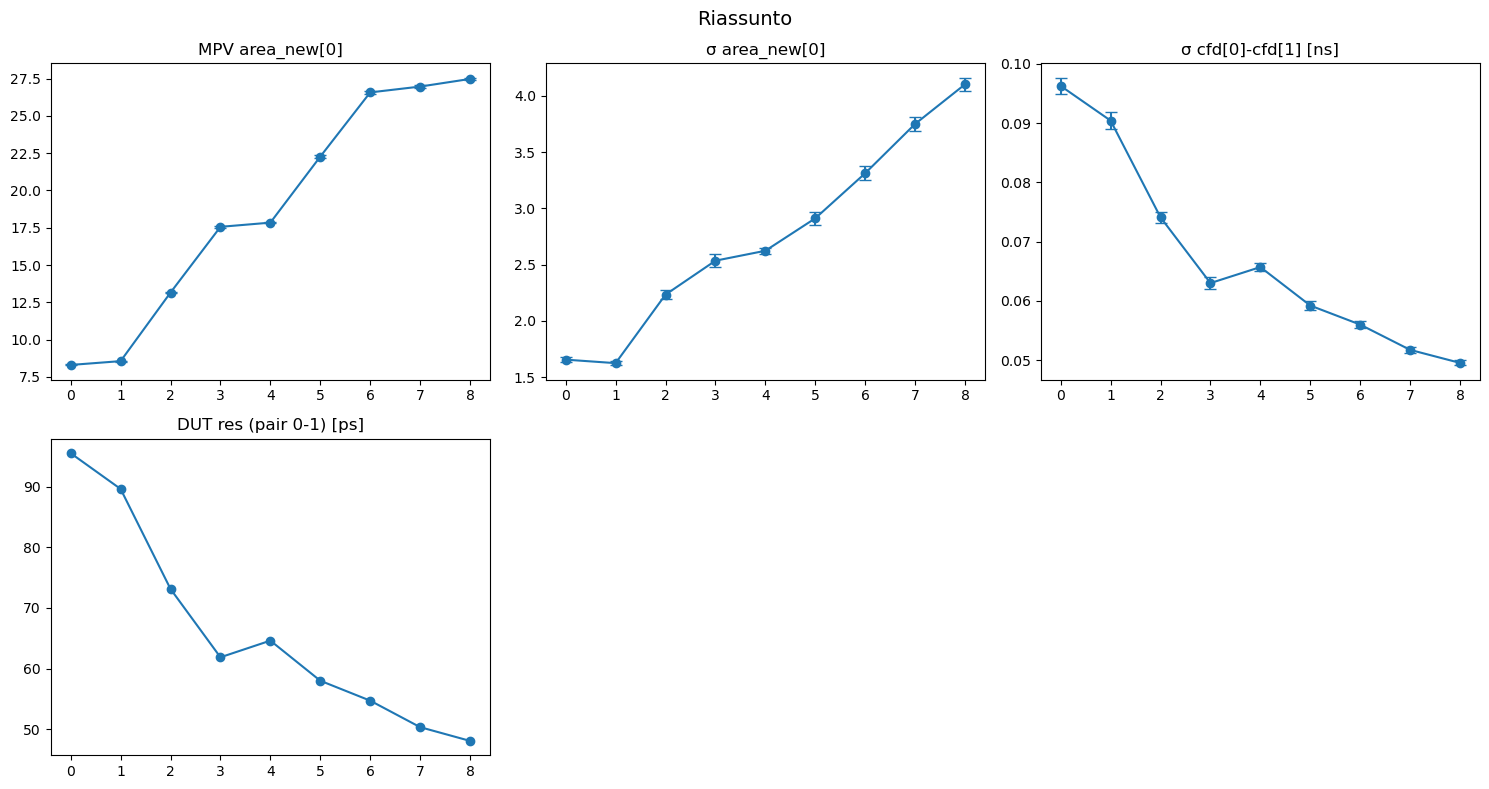

In [ ]:
df_r = pd.DataFrame(results)
x = df_r['idx'].values

plot_items = []
for ch in DUT_CHANNELS:
    plot_items.append((f'mpv{ch}',   f'mpv{ch}_err',   f'MPV area_new[{ch}]'))
    plot_items.append((f'sigma{ch}', f'sigma{ch}_err', f'σ area_new[{ch}]'))
for (a, b) in PAIRS:
    plot_items.append((f'sg{a}{b}', f'sg{a}{b}_e', f'σ cfd[{a}]-cfd[{b}] [ns]'))
    if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
        rkey = f'res{a}{b}_ps'
        if rkey in df_r.columns:
            plot_items.append((rkey, None, f'DUT res (pair {a}-{b}) [ps]'))

ncols = 3
nrows = max(1, int(np.ceil(len(plot_items) / ncols)))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)
fig.suptitle("Riassunto", fontsize=14)

for idx, (col, col_e, title) in enumerate(plot_items):
    row, c = divmod(idx, ncols)
    ax = axes[row][c]
    if col_e:
        ax.errorbar(x, df_r[col], yerr=df_r[col_e], fmt='o-', capsize=4)
    else:
        ax.plot(x, df_r[col], 'o-')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(range(len(x)))

for idx in range(len(plot_items), nrows * ncols):
    row, c = divmod(idx, ncols)
    axes[row][c].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# ── Lista per Excel ──────────────────────────────────────────────────────────
# Seleziona tutto l'output, copia, incolla direttamente su Excel

import pandas as pd

df = pd.DataFrame(results)

# Coincidenze per ogni pair
for (a, b) in PAIRS:
    coinc = []
    for i, filepath in enumerate(root_files):
        with uproot.open(filepath) as f:
            pmax_ak = f["Analysis"]["pmax"].array(library="ak")
        pma = ak.to_numpy(pmax_ak[:, a]).astype(float)
        pmb = ak.to_numpy(pmax_ak[:, b]).astype(float)
        coinc.append(int(np.sum((pma > cuts_pmax[a][i]) & (pmb > cuts_pmax[b][i]))))
    df[f'coinc_{a}{b}'] = coinc

# CFD sigma da ns a ps
for (a, b) in PAIRS:
    df[f'sg{a}{b}_ps'] = df[f'sg{a}{b}'] * 1000

# Colonne output
cols = {'file': 'File'}
for ch in DUT_CHANNELS:
    cols[f'mpv{ch}']   = f'MPV area_new[{ch}]'
    cols[f'sigma{ch}'] = f'sigma area_new[{ch}]'
for (a, b) in PAIRS:
    cols[f'sg{a}{b}_ps'] = f'sigma cfd[{a}]-cfd[{b}] [ps]'
    if HAS_MCP and (a == MCP_CHANNEL or b == MCP_CHANNEL):
        cols[f'res{a}{b}_ps'] = f'DUT resolution (pair {a}-{b}) [ps]'
    cols[f'coinc_{a}{b}'] = f'coincidenze {a}-{b}'

df_out = df[[c for c in cols if c in df.columns]].rename(columns=cols)
print(df_out.to_csv(sep='\t', index=False, float_format='%.3f', decimal=','))

File	MPV area_new[0]	sigma area_new[0]	sigma cfd[0]-cfd[1] [ps]	DUT resolution (pair 0-1) [ps]	coincidenze 0-1
stats_Sr_Run12_Ch0-300V_trig2750V.root	8,294	1,656	96,264	95,514	1555
stats_Sr_Run12_Ch0-350V_trig2750V.root	8,550	1,625	90,417	89,617	2233
stats_Sr_Run12_Ch0-400V_trig2750V.root	13,151	2,234	74,100	73,122	1125
stats_Sr_Run12_Ch0-450V_trig2750V.root	17,562	2,535	63,008	61,855	925
stats_Sr_Run12_Ch0-500V_trig2750V.root	17,843	2,623	65,707	64,602	1742
stats_Sr_Run12_Ch0-525V_trig2750V.root	22,273	2,911	59,217	57,988	1382
stats_Sr_Run12_Ch0-550V_trig2750V.root	26,582	3,312	56,001	54,700	1149
stats_Sr_Run12_Ch0-575V_trig2750V.root	26,973	3,749	51,741	50,331	1733
stats_Sr_Run12_Ch0-600V_trig2750V.root	27,486	4,101	49,540	48,064	2368

